# Geothermal Binary ORC Simulator — Demonstration

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/khb-git/geothermal-orc/blob/main/notebooks/demo.ipynb)
&nbsp;
[![View on nbviewer](https://raw.githubusercontent.com/jupyter/design/master/logos/Badges/nbviewer_badge.svg)](https://nbviewer.org/github/khb-git/geothermal-orc/blob/main/notebooks/demo.ipynb)

**`geothermal-orc`** is a single, deep implementation of a subcritical binary
(Organic Rankine Cycle) geothermal power plant, built for literature-grade
rigor. This notebook walks the full modelling chain:

1. Working-fluid library with environmental screening (ODP / GWP / ASHRAE safety)
2. The four-point ORC cycle and its *T*–*s* diagram
3. The evaporator pinch via a swept *T*–*Q* profile
4. Resource coupling — sizing the plant to a brine stream with closed
   **energy and exergy** balances
5. Evaporation-temperature **optimization** and multi-fluid **screening**
6. **Silica scaling** chemistry and the reinjection-temperature floor
7. **Resource thermal decline** over field life

**Literature anchors.** Cycle conventions follow DiPippo, *Geothermal Power
Plants* (2016); fluid screening follows Saleh et al. (2007); silica solubility
uses Fournier & Rowe (1977); decline rates follow Snyder et al. (2017).
Throughout, computed numbers are cross-checked against published values, and
the notebook is explicit about which checks are hard validations versus
order-of-magnitude plausibility checks.


In [1]:
# Setup. On Colab / Binder this installs the package; locally it is a no-op.
try:
    import geothermal_orc  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/khb-git/geothermal-orc.git"],
        check=True,
    )

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

import geothermal_orc as g
from geothermal_orc import (
    LIBRARY, get_fluid, screen, ORCCycle, counterflow_profile,
    GeothermalResource, optimize_evaporation_temperature, screen_fluids,
    amorphous_silica_solubility, quartz_solubility, quartz_geothermometer,
)

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "axes.axisbelow": True,
})
print("geothermal-orc version:", g.__version__)
print("fluids in library:", len(LIBRARY))

geothermal-orc version: 0.1.0
fluids in library: 14


## 1. Working-fluid library and environmental screening

The library carries each fluid's critical point, normal boiling point,
ASHRAE-34 safety class, ozone-depletion potential (ODP), 100-year global-warming
potential (GWP), and a **wet / dry / isentropic** classification of its
saturation-vapour curve. The classifier measures the slope d*s*/d*T* along the
saturated-vapour line near 0.7·*T*c; dry and isentropic fluids are preferred for
binary plants because they leave the turbine without forming damaging liquid.

In [3]:
import pandas as pd

rows = []
for f in sorted(LIBRARY.values(), key=lambda x: x.Tcrit):
    rows.append({
        "fluid": f.display_name, "ASHRAE": f.ashrae, "family": f.family,
        "Tcrit [C]": round(f.Tcrit - 273.15, 1),
        "Tnbp [C]": round(f.Tnbp - 273.15, 1),
        "type": f.slope_type, "safety": f.safety,
        "ODP": f.odp, "GWP100": f.gwp100,
    })
df = pd.DataFrame(rows)
df

,fluid,ASHRAE,family,Tcrit [C],Tnbp [C],type,safety,ODP,GWP100
0,R1234yf,R1234yf,HFO,94.7,-29.5,isentropic,A2L,0.0,4.0
1,Propane,R290,alkane,96.7,-42.1,wet,A3,0.0,3.0
2,R134a,R134a,HFC,101.1,-26.1,wet,A1,0.0,1430.0
3,R227ea,R227ea,HFC,101.8,-16.3,dry,A1,0.0,3220.0
4,R1234ze(E),R1234ze,HFO,109.4,-19.0,isentropic,A2L,0.0,7.0
5,R152a,R152a,HFC,113.3,-24.0,wet,A2,0.0,124.0
6,R236fa,R236fa,HFC,124.9,-1.5,dry,A1,0.0,9810.0
7,Ammonia,R717,natural,132.4,-33.3,wet,B2L,0.0,0.0
8,Isobutane,R600a,alkane,134.7,-11.7,dry,A3,0.0,3.0
9,n-Butane,R600,alkane,152.0,-0.5,dry,A3,0.0,4.0


**Screening.** A common modern screen keeps fluids that are not strongly
*wet*, have zero ODP, and modest GWP. `screen()` applies such criteria; here we
keep dry / isentropic fluids with GWP100 below 150 (the EU F-gas threshold
often cited for new equipment).

passed screen: ['R1234yf', 'R1234ze(E)', 'Isobutane', 'n-Butane', 'Isopentane', 'n-Pentane', 'Cyclopentane']


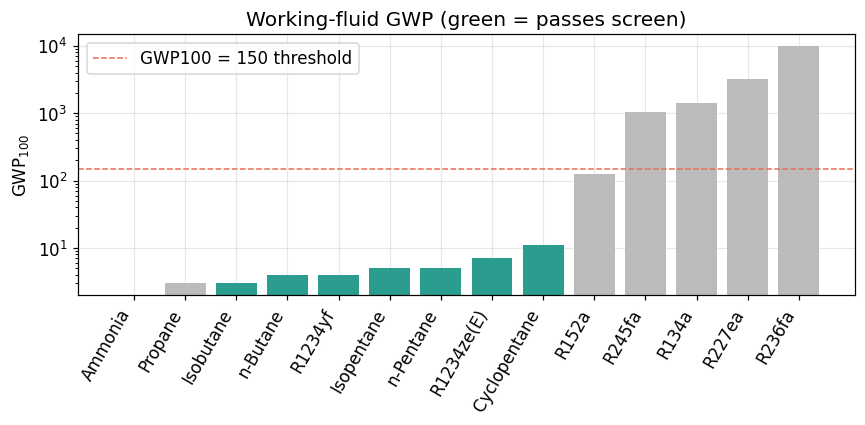

In [4]:
kept = screen(max_gwp=150, max_odp=0.0, slope_types=["dry", "isentropic"])
print("passed screen:", [f.display_name for f in kept])

fig, ax = plt.subplots(figsize=(8, 4))
names = [f.display_name for f in sorted(LIBRARY.values(), key=lambda x: x.gwp100)]
gwps = [get_fluid(n).gwp100 for n in names]
kept_names = {f.display_name for f in kept}
colors = ["#2a9d8f" if n in kept_names else "#bbbbbb" for n in names]
ax.bar(names, gwps, color=colors)
ax.axhline(150, color="#e76f51", ls="--", lw=1, label="GWP100 = 150 threshold")
ax.set_ylabel("GWP$_{100}$"); ax.set_yscale("log")
ax.set_title("Working-fluid GWP (green = passes screen)")
plt.xticks(rotation=60, ha="right"); ax.legend(); plt.tight_layout(); plt.show()

## 2. The binary ORC cycle and its *T*–*s* diagram

State-point numbering follows DiPippo (2016):

| point | location | condition |
|------|----------|-----------|
| 1 | condenser outlet / pump inlet | saturated liquid at $P_\text{cond}$ |
| 2 | pump outlet | compressed liquid at $P_\text{evap}$ |
| 3 | evaporator outlet / turbine inlet | saturated (or superheated) vapour |
| 4 | turbine outlet / condenser inlet | two-phase or superheated at $P_\text{cond}$ |

We use **isobutane** (R600a), a workhorse binary fluid, evaporating at 120 °C
and condensing at 30 °C, with realistic pump/turbine efficiencies.

In [5]:
cyc = ORCCycle("Isobutane", T_evap_C=120.0, T_cond_C=30.0,
               eta_pump=0.75, eta_turbine=0.80)
res = cyc.solve()
print(res.summary())
print(f"\nturbine exit quality Q4 = {res.turbine_exit_quality:.3f} "
      f"(-1 means superheated -> 'dry' expansion, no droplets)")

ORC (Isobutane)
  eta_th        =  12.95 %
  eta_carnot    =  22.89 %
  w_net         =  53.02 kJ/kg

turbine exit quality Q4 = -1.000 (-1 means superheated -> 'dry' expansion, no droplets)


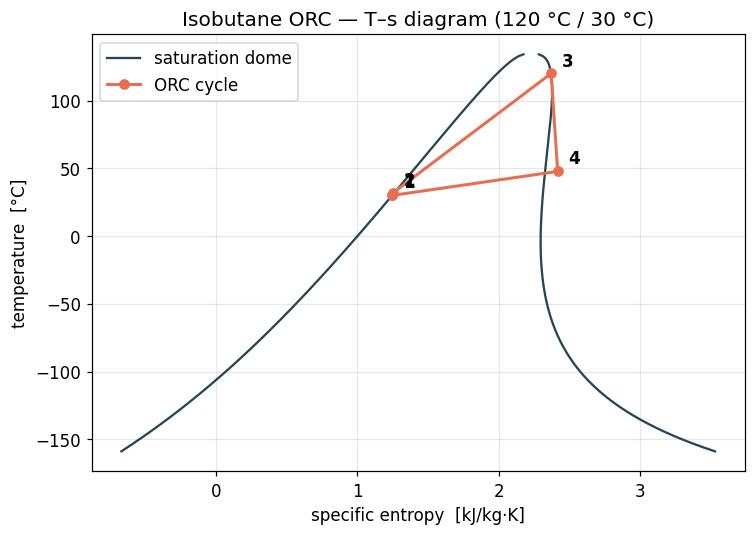

In [6]:
# Saturation dome + cycle path on T-s axes.
fluid = "Isobutane"
Tt = PropsSI("Ttriple", fluid); Tc = PropsSI("Tcrit", fluid)
Ts = np.linspace(Tt + 0.5, Tc - 0.5, 200)
s_liq = [PropsSI("S", "T", T, "Q", 0, fluid) for T in Ts]
s_vap = [PropsSI("S", "T", T, "Q", 1, fluid) for T in Ts]

st = res.states
order = [1, 2, 3, 4, 1]
s_pts = [st[i].s for i in order]
T_pts = [st[i].T for i in order]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(np.array(s_liq) / 1e3, Ts - 273.15, color="#264653", lw=1.5)
ax.plot(np.array(s_vap) / 1e3, Ts - 273.15, color="#264653", lw=1.5,
        label="saturation dome")
ax.plot(np.array(s_pts) / 1e3, np.array(T_pts) - 273.15, "o-",
        color="#e76f51", lw=2, label="ORC cycle")
for i in [1, 2, 3, 4]:
    ax.annotate(str(i), (st[i].s / 1e3, st[i].T - 273.15),
                textcoords="offset points", xytext=(7, 5), fontweight="bold")
ax.set_xlabel("specific entropy  [kJ/kg·K]")
ax.set_ylabel("temperature  [°C]")
ax.set_title(f"{fluid} ORC — T–s diagram (120 °C / 30 °C)")
ax.legend(); plt.tight_layout(); plt.show()

## 3. Evaporator pinch and the *T*–*Q* diagram

The evaporator is the component where a terminal-only LMTD check fails: as the
working fluid reaches its bubble point its temperature plateaus, so the minimum
hot–cold approach (the **pinch**) usually sits *inside* the exchanger rather
than at either end. `counterflow_profile` sweeps the exchanger by duty so the
pinch is found correctly. We couple to a 150 °C brine at 100 kg/s and size the
working-fluid flow so the pinch equals 5 K.

working-fluid flow m_wf = 71.67 kg/s
evaporator duty        = 29.33 MW
pinch                  = 5.00 K  (target 5 K)
brine outlet           = 80.81 °C


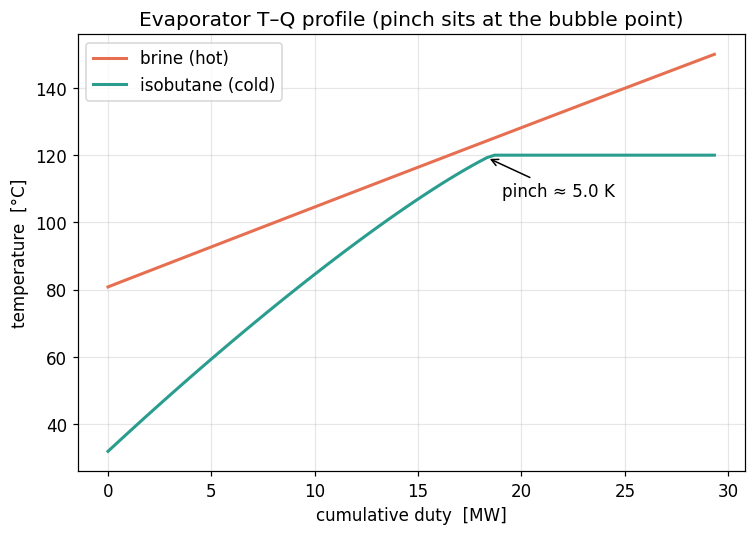

In [7]:
full = cyc.solve_with_resource(m_brine=100.0, T_brine_in_C=150.0,
                               pinch_evap=5.0)
ev = full.evaporator
print(f"working-fluid flow m_wf = {full.m_wf:.2f} kg/s")
print(f"evaporator duty        = {full.Q_in/1e6:.2f} MW")
print(f"pinch                  = {ev.pinch:.2f} K  (target 5 K)")
print(f"brine outlet           = {full.brine_T_out-273.15:.2f} °C")

fig, ax = plt.subplots(figsize=(7, 5))
Qcum = ev.duty / 1e6
ax.plot(Qcum, ev.T_hot - 273.15, color="#e76f51", lw=2, label="brine (hot)")
ax.plot(Qcum, ev.T_cold - 273.15, color="#2a9d8f", lw=2,
        label="isobutane (cold)")
i_p = int(np.argmin(ev.T_hot - ev.T_cold))
ax.annotate(f"pinch ≈ {ev.pinch:.1f} K",
            (Qcum[i_p], ev.T_cold[i_p] - 273.15),
            textcoords="offset points", xytext=(10, -25),
            arrowprops=dict(arrowstyle="->"))
ax.set_xlabel("cumulative duty  [MW]"); ax.set_ylabel("temperature  [°C]")
ax.set_title("Evaporator T–Q profile (pinch sits at the bubble point)")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Resource coupling — energy and exergy balances

With the plant sized to the brine, the solver assembles full **rate** balances
and checks closure. Two checks are reported:

* **Energy:** $Q_\text{in} - Q_\text{out} - W_\text{net} = 0$
* **Exergy:** $\dot E_\text{in} = W_\text{net} + \dot E_\text{out} +
  \sum \dot E_\text{dest}$

with exergy destruction per component computed as $T_0\,\dot S_\text{gen}$. Both
residuals should close to machine precision — that is the core correctness
guarantee the test-suite asserts.

In [8]:
print(f"W_net            = {full.W_net/1e6:7.3f} MW")
print(f"Q_in             = {full.Q_in/1e6:7.3f} MW")
print(f"Q_out            = {full.Q_out/1e6:7.3f} MW")
print(f"util. efficiency = {full.eta_utilization*100:6.2f} %  (2nd-law, vs brine exergy)")
print(f"thermal eff.     = {full.eta_th*100:6.2f} %")
print()
print(f"energy residual  = {full.energy_balance_residual:.2e}")
print(f"exergy residual  = {full.exergy_balance_residual:.2e}")

W_net            =   3.800 MW


Q_in             =  29.333 MW
Q_out            =  25.533 MW
util. efficiency =  43.13 %  (2nd-law, vs brine exergy)
thermal eff.     =  12.95 %

energy residual  = 7.94e-17
exergy residual  = 2.88e-14


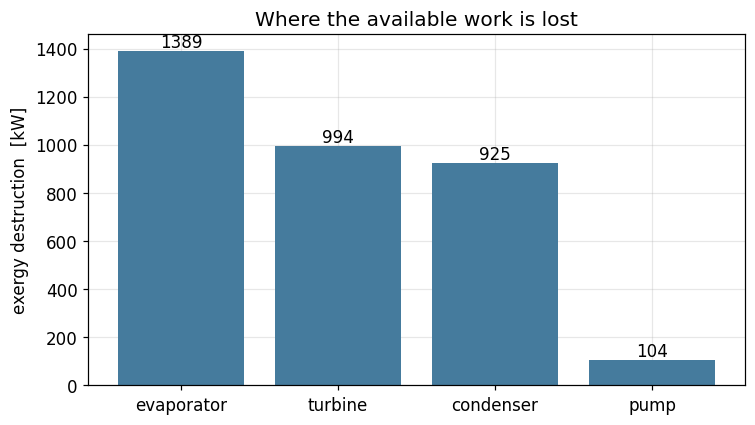

In [9]:
ed = full.exergy_destruction
comp = list(ed.keys()); vals = [ed[c] / 1e3 for c in comp]
o = np.argsort(vals)[::-1]
comp = [comp[i] for i in o]; vals = [vals[i] for i in o]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comp, vals, color="#457b9d")
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:.0f}", ha="center", va="bottom")
ax.set_ylabel("exergy destruction  [kW]")
ax.set_title("Where the available work is lost")
plt.tight_layout(); plt.show()

## 5. Optimizing the evaporation temperature

Net power is non-monotonic in evaporation temperature: raising it lifts cycle
efficiency but shrinks the working-fluid flow the brine can support (the pinch
tightens). The optimum sits in between. We sweep $T_\text{evap}$ and overlay the
optimizer's result.

optimum: T_evap = 97.5 °C, W_net = 4.209 MW


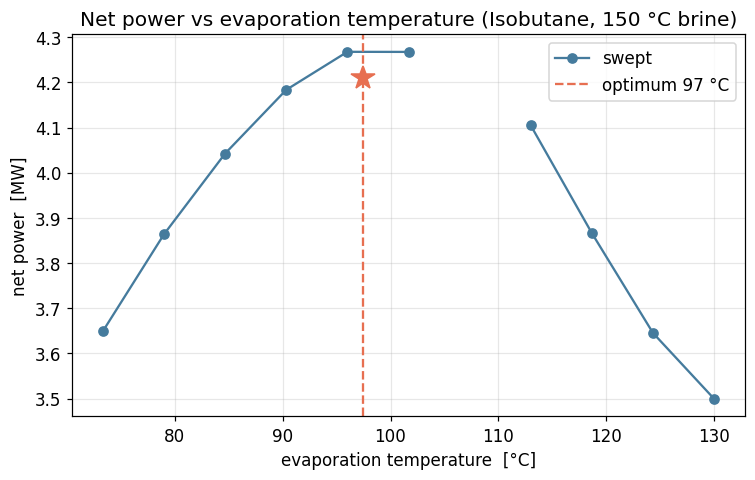

In [10]:
resource = GeothermalResource(T_reservoir_C=150.0, mass_flow=100.0)

T_sweep = np.linspace(45, 130, 16)
W_sweep = []
for Te in T_sweep:
    try:
        r = ORCCycle("Isobutane", T_evap_C=float(Te), T_cond_C=30.0
                     ).solve_with_resource(m_brine=100.0, T_brine_in_C=150.0,
                                           pinch_evap=5.0, n=40, n_search=24)
        W_sweep.append(r.W_net / 1e6)
    except Exception:
        W_sweep.append(np.nan)

opt = optimize_evaporation_temperature("Isobutane", resource, T_cond_C=30.0)
print(f"optimum: T_evap = {opt.T_evap_opt_C:.1f} °C, "
      f"W_net = {opt.W_net_opt/1e6:.3f} MW")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(T_sweep, W_sweep, "o-", color="#457b9d", label="swept")
ax.axvline(opt.T_evap_opt_C, color="#e76f51", ls="--",
           label=f"optimum {opt.T_evap_opt_C:.0f} °C")
ax.plot(opt.T_evap_opt_C, opt.W_net_opt / 1e6, "*", color="#e76f51",
        markersize=16)
ax.set_xlabel("evaporation temperature  [°C]")
ax.set_ylabel("net power  [MW]")
ax.set_title("Net power vs evaporation temperature (Isobutane, 150 °C brine)")
ax.legend(); plt.tight_layout(); plt.show()

## 6. Multi-fluid screening at the resource

Each candidate fluid is independently optimized over its evaporation
temperature, then ranked by net power. This is the practical output a designer
wants: *for this brine, which fluid wins, and by how much?*

fluid         T_evap [C]  W_net [MW]  feasible
Propane             90.3       4.352      True
Isobutane           97.5       4.209      True
R245fa              93.3       4.014      True
n-Butane            93.8       3.987      True
Isopentane          92.1       3.861      True
n-Pentane           94.8       3.807      True


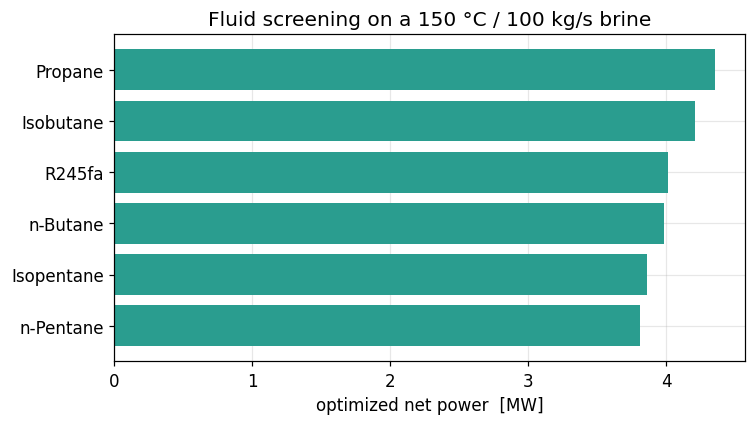

In [11]:
candidates = ["Propane", "Isobutane", "n-Butane",
              "Isopentane", "n-Pentane", "R245fa"]
ranked = screen_fluids(candidates, resource, T_cond_C=30.0)

print(f"{'fluid':<12}{'T_evap [C]':>12}{'W_net [MW]':>12}{'feasible':>10}")
for r in ranked:
    print(f"{r.fluid:<12}{r.T_evap_opt_C:>12.1f}"
          f"{r.W_net_opt/1e6:>12.3f}{str(r.feasible):>10}")

feas = [r for r in ranked if r.feasible]
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([r.fluid for r in feas][::-1],
        [r.W_net_opt / 1e6 for r in feas][::-1], color="#2a9d8f")
ax.set_xlabel("optimized net power  [MW]")
ax.set_title("Fluid screening on a 150 °C / 100 kg/s brine")
plt.tight_layout(); plt.show()

## 7. Silica scaling and the reinjection floor

Dissolved silica limits how cold the brine may be reinjected: cool it too far
and amorphous silica supersaturates and scales the injection system. The model
uses Fournier & Rowe (1977):

$$\log_{10} C = -\tfrac{731}{T} + 4.52 \quad\text{(amorphous, mg/kg, }T\text{ in K)}$$
$$\log_{10} C = -\tfrac{1309}{T} + 5.19 \quad\text{(quartz)}$$

**Validation against literature.** The table below compares computed
solubilities with published values.

In [12]:
checks = [
    ("amorphous", amorphous_silica_solubility, 25.0, "115–120"),
    ("amorphous", amorphous_silica_solubility, 100.0, "~370"),
    ("quartz",    quartz_solubility,           100.0, "48–52"),
    ("quartz",    quartz_solubility,           150.0, "~125"),
]
print(f"{'curve':<11}{'T [C]':>7}{'computed':>11}{'literature':>14}")
for name, fn, Tc, lit in checks:
    val = fn(Tc + 273.15)
    print(f"{name:<11}{Tc:>7.0f}{val:>11.1f}{lit:>14}")

# Round-trip the quartz geothermometer: C(200C) -> T should recover 200C.
C200 = quartz_solubility(200 + 273.15)
print(f"\nquartz geothermometer round-trip: "
      f"C(200°C)={C200:.1f} mg/kg -> T={quartz_geothermometer(C200):.1f} °C")

curve        T [C]   computed    literature
amorphous       25      117.0       115–120
amorphous      100      363.9          ~370
quartz         100       48.1         48–52
quartz         150      124.9          ~125

quartz geothermometer round-trip: C(200°C)=265.1 mg/kg -> T=201.0 °C


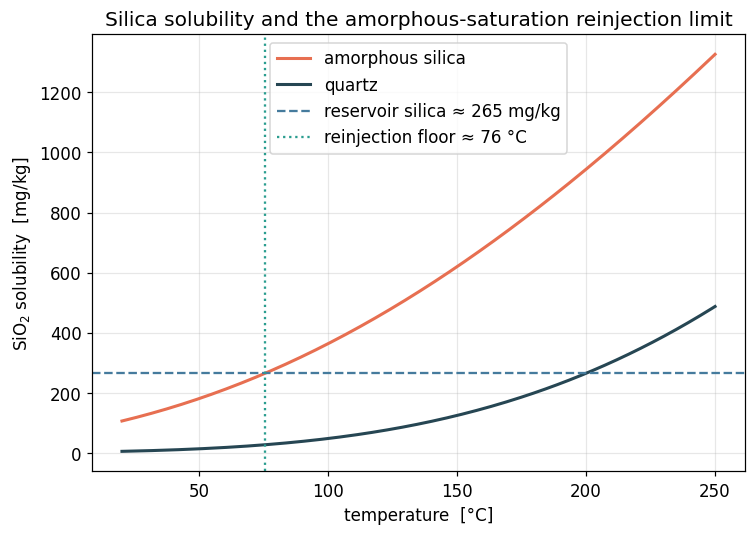

200 °C reservoir, quartz-equilibrium silica = 265.1 mg/kg
amorphous-saturation (SI=1) reinjection floor = 75.5 °C


In [13]:
TC = np.linspace(20, 250, 200)
amorph = [amorphous_silica_solubility(T + 273.15) for T in TC]
quartz = [quartz_solubility(T + 273.15) for T in TC]

rich = GeothermalResource(T_reservoir_C=200.0, mass_flow=100.0)
C_res = rich.silica_mgkg
T_floor = rich.min_reinjection_temperature(1.0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(TC, amorph, color="#e76f51", lw=2, label="amorphous silica")
ax.plot(TC, quartz, color="#264653", lw=2, label="quartz")
ax.axhline(C_res, color="#457b9d", ls="--",
           label=f"reservoir silica ≈ {C_res:.0f} mg/kg")
ax.axvline(T_floor, color="#2a9d8f", ls=":",
           label=f"reinjection floor ≈ {T_floor:.0f} °C")
ax.set_xlabel("temperature  [°C]"); ax.set_ylabel("SiO$_2$ solubility  [mg/kg]")
ax.set_title("Silica solubility and the amorphous-saturation reinjection limit")
ax.legend(); plt.tight_layout(); plt.show()

print(f"200 °C reservoir, quartz-equilibrium silica = {C_res:.1f} mg/kg")
print(f"amorphous-saturation (SI=1) reinjection floor = {T_floor:.1f} °C")

## 8. Resource thermal decline over field life

Production temperature falls as the reservoir is mined of heat. Snyder et al.
(2017), analysing operating US binary and flash plants, found most wells decline
**linearly**, averaging roughly **0.5 %/yr for binary** and **0.8 %/yr for
flash**. The defaults encode those rates; here we propagate a 150 °C binary
resource over 30 years and translate the temperature decline into optimized
plant power.

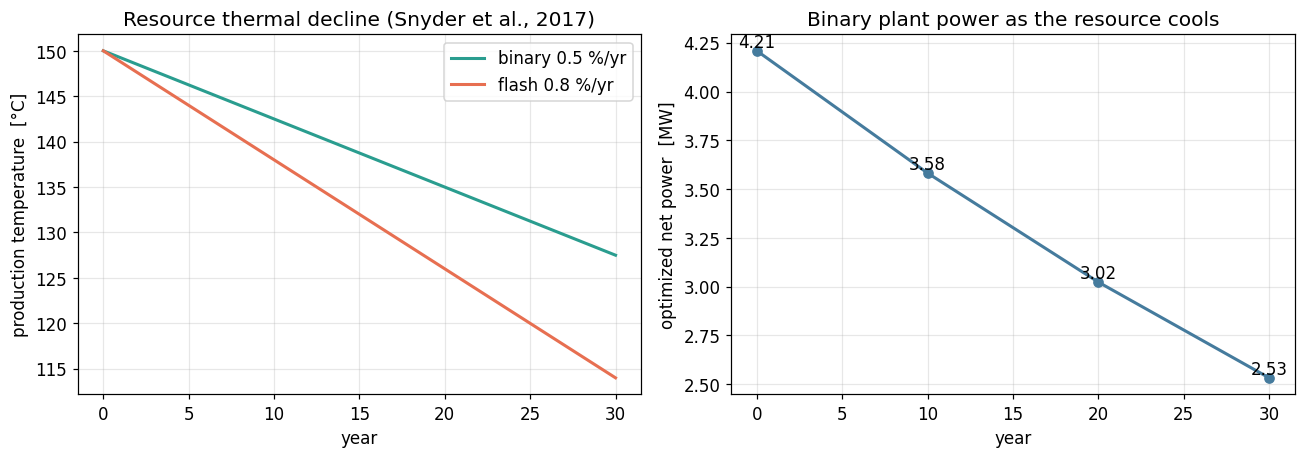

year :  T[C]  ->  P[MW]
   0 :  150.0  ->  4.209
  10 :  142.5  ->  3.582
  20 :  135.0  ->  3.023
  30 :  127.5  ->  2.533


In [14]:
years = np.arange(0, 31)
binary = GeothermalResource(T_reservoir_C=150.0, mass_flow=100.0,
                            decline_rate=0.005, decline_mode="linear")
flash = GeothermalResource(T_reservoir_C=150.0, mass_flow=100.0,
                           decline_rate=0.008, decline_mode="linear")
T_bin = [binary.temperature_at(y) for y in years]
T_fl = [flash.temperature_at(y) for y in years]

# Plant power at years 0, 10, 20, 30 (re-optimized as the resource cools).
sample_years = [0, 10, 20, 30]
P_years = []
for y in sample_years:
    res_y = GeothermalResource(T_reservoir_C=binary.temperature_at(y),
                               mass_flow=100.0)
    o = optimize_evaporation_temperature("Isobutane", res_y, T_cond_C=30.0)
    P_years.append(o.W_net_opt / 1e6)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.3))
a1.plot(years, T_bin, color="#2a9d8f", lw=2, label="binary 0.5 %/yr")
a1.plot(years, T_fl, color="#e76f51", lw=2, label="flash 0.8 %/yr")
a1.set_xlabel("year"); a1.set_ylabel("production temperature  [°C]")
a1.set_title("Resource thermal decline (Snyder et al., 2017)"); a1.legend()

a2.plot(sample_years, P_years, "o-", color="#457b9d", lw=2)
a2.set_xlabel("year"); a2.set_ylabel("optimized net power  [MW]")
a2.set_title("Binary plant power as the resource cools")
for x, p in zip(sample_years, P_years):
    a2.text(x, p, f"{p:.2f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

print("year :  T[C]  ->  P[MW]")
for y, p in zip(sample_years, P_years):
    print(f"{y:4d} : {binary.temperature_at(y):6.1f}  -> {p:6.3f}")

## 9. Interactive design explorer

The cell below defines `plot_design`, which — for a chosen working fluid, brine
inlet temperature, condensing temperature, and pinch — runs a quick internal
search over evaporation temperature, then reports net power, utilization
efficiency, brine outlet temperature, and the evaporator *T*–*Q* diagram. The
static figure here is the default configuration (isobutane, 150 °C brine).

**To move the controls live**, open this notebook in Colab (badge at the top)
and run all cells; the cell after this one turns these four inputs into
sliders. GitHub shows a static frame because its viewer cannot run a kernel.

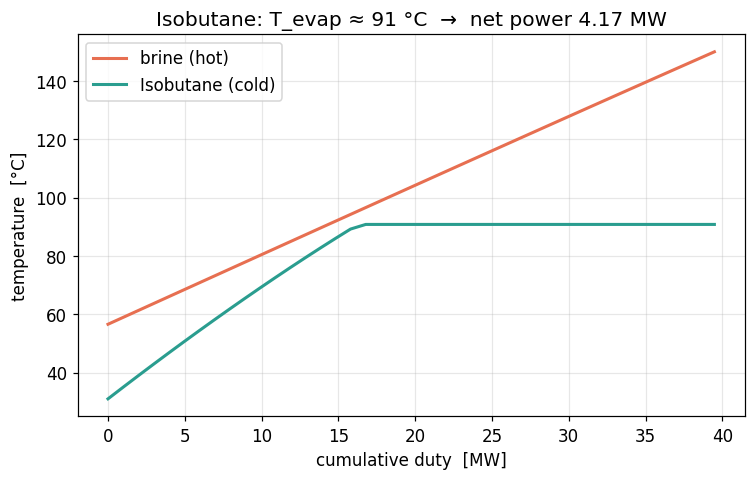

net power         =   4.17 MW
utilization eff.  =  47.31 %
brine outlet      =   56.6 °C
working-fluid flow=  100.1 kg/s   (T_evap ≈ 91 °C)


In [15]:
def plot_design(fluid="Isobutane", T_brine=150.0, T_cond=30.0, pinch=5.0):
    # Quick near-optimal design for a 100 kg/s brine, with a T-Q plot.
    Tc_C = PropsSI("Tcrit", fluid) - 273.15
    lo, hi = T_cond + 5.0, min(Tc_C - 2.0, T_brine - pinch - 1.0)
    best, bestTe = None, None
    if hi > lo:
        for Te in np.linspace(lo, hi, 8):
            try:
                r = ORCCycle(fluid, T_evap_C=float(Te), T_cond_C=T_cond
                             ).solve_with_resource(
                                 m_brine=100.0, T_brine_in_C=T_brine,
                                 pinch_evap=pinch, n=40, n_search=24)
            except Exception:
                continue
            if best is None or r.W_net > best.W_net:
                best, bestTe = r, float(Te)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    if best is None:
        ax.text(0.5, 0.5, "infeasible configuration", ha="center", va="center")
        ax.axis("off"); plt.show()
        print("No feasible design for these settings.")
        return
    ev = best.evaporator
    ax.plot(ev.duty / 1e6, ev.T_hot - 273.15, color="#e76f51", lw=2,
            label="brine (hot)")
    ax.plot(ev.duty / 1e6, ev.T_cold - 273.15, color="#2a9d8f", lw=2,
            label=f"{fluid} (cold)")
    ax.set_xlabel("cumulative duty  [MW]"); ax.set_ylabel("temperature  [°C]")
    ax.set_title(f"{fluid}: T_evap ≈ {bestTe:.0f} °C  →  "
                 f"net power {best.W_net/1e6:.2f} MW")
    ax.legend(); plt.tight_layout(); plt.show()
    print(f"net power         = {best.W_net/1e6:6.2f} MW")
    print(f"utilization eff.  = {best.eta_utilization*100:6.2f} %")
    print(f"brine outlet      = {best.brine_T_out-273.15:6.1f} °C")
    print(f"working-fluid flow= {best.m_wf:6.1f} kg/s   (T_evap ≈ {bestTe:.0f} °C)")


# Static default configuration (this frame is what GitHub shows).
plot_design()

In [ ]:
# Live controls — runs in Colab / Jupyter (Run All). On GitHub this stays
# static; the snapshot above is the default configuration.
import ipywidgets as widgets
from ipywidgets import interact

fluid_opts = ["Propane", "Isobutane", "n-Butane", "Isopentane",
              "n-Pentane", "Cyclopentane", "R245fa"]

interact(
    plot_design,
    fluid=widgets.Dropdown(options=fluid_opts, value="Isobutane",
                           description="fluid"),
    T_brine=widgets.FloatSlider(min=110, max=200, step=5, value=150,
                                description="brine °C", continuous_update=False),
    T_cond=widgets.FloatSlider(min=20, max=45, step=1, value=30,
                               description="cond °C", continuous_update=False),
    pinch=widgets.FloatSlider(min=2, max=12, step=0.5, value=5,
                              description="pinch K", continuous_update=False),
);

## Summary

The simulator carries a geothermal binary plant from a working-fluid choice
through cycle thermodynamics, evaporator pinch analysis, resource-coupled
energy/exergy balances, evaporation-temperature optimization and fluid
screening, and the two chemistry/longevity constraints that bound real
designs — silica scaling and thermal decline.

**Validation status (transparent):**

* **Hard validations** — silica solubilities (amorphous & quartz) and the
  quartz geothermometer round-trip match Fournier & Rowe to within a few
  mg/kg; energy and exergy balances close to machine precision; fluid
  wet/dry/isentropic classes match the literature consensus.
* **Plausibility checks** — absolute plant net power, utilization efficiency,
  and brine outlet temperatures fall in the ranges reported by DiPippo for
  comparable 150 °C binary resources, but are not matched to a specific named
  plant.

**References**

* R. DiPippo, *Geothermal Power Plants: Principles, Applications, Case Studies
  and Environmental Impact*, 4th ed., Butterworth-Heinemann, 2016.
* B. Saleh, G. Koglbauer, M. Wendland, J. Fischer, "Working fluids for
  low-temperature organic Rankine cycles," *Energy* 32 (2007) 1210–1221.
* R. O. Fournier, J. J. Rowe, "The solubility of amorphous silica in water at
  high temperatures and high pressures," *Am. Mineral.* 62 (1977) 1052–1056.
* D. M. Snyder, K. F. Beckers, K. R. Young, "Update on geothermal
  direct-use and power-plant thermal decline," *GRC Transactions* 41 (2017).
